
==================== INSTALL LIBRARY ====================


==================== IMPORT LIBRARY ====================

Library berhasil di-import.

==================== UPLOAD GAMBAR ====================

Upload 2 gambar: (1) Referensi Lurus, (2) Gambar Miring)



Saving doc_lurus.jpg to doc_lurus (6).jpg
Saving doc_miring.jpg to doc_miring (6).jpg

Gambar berhasil dimuat dan disamakan ukurannya.

==================== DEFINISI FUNGSI EVALUASI ====================

Fungsi MSE dan PSNR siap digunakan.

==================== TRANSLASI ====================

Translasi selesai.

==================== ROTASI ====================

Rotasi selesai.

==================== SCALING ====================

Scaling selesai.

==================== TRANSFORMASI AFFINE ====================

Affine selesai.

==================== TRANSFORMASI PERSPEKTIF ====================

Perspective + 3 interpolasi selesai.

==================== VISUALISASI TRANSFORMASI ====================



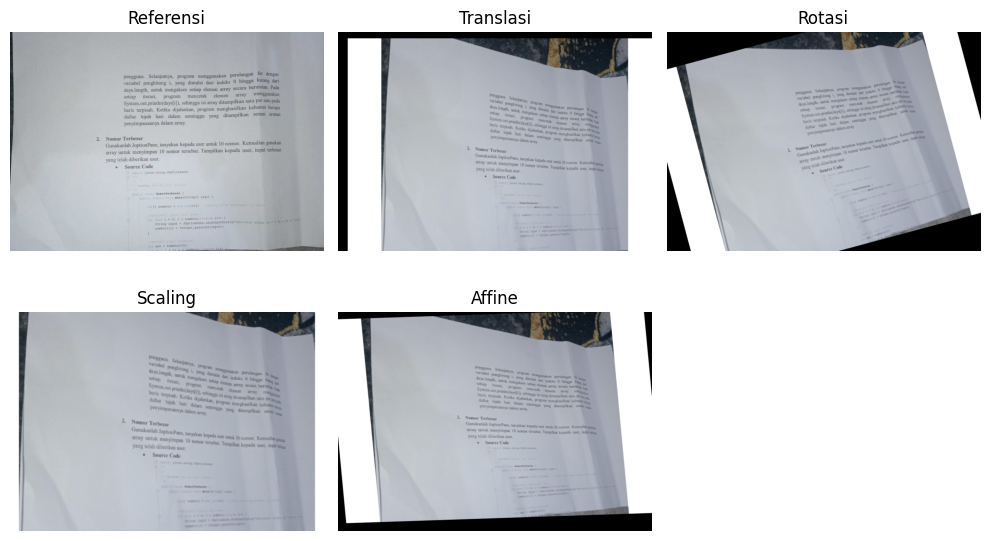


==================== VISUALISASI INTERPOLASI PERSPEKTIF ====================



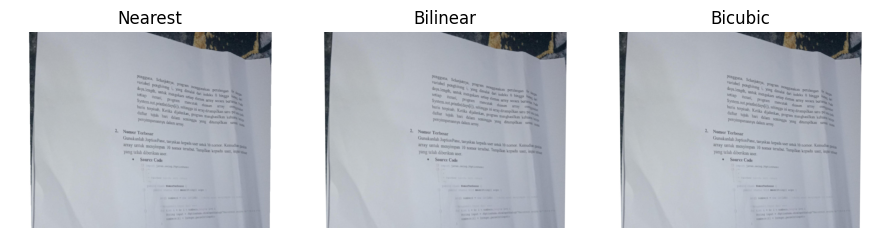


==================== HASIL EVALUASI ====================

Translasi
MSE  : 4175.744
PSNR : 11.9235
Time : 0.0083 detik

Rotasi
MSE  : 5106.4155
PSNR : 11.0496
Time : 0.00924 detik

Scaling
MSE  : 1488.4971
PSNR : 16.4033
Time : 0.00812 detik

Affine
MSE  : 5176.557
PSNR : 10.9904
Time : 0.00888 detik

Persp_Nearest
MSE  : 2204.53
PSNR : 14.6976
Time : 0.0078 detik

Persp_Bilinear
MSE  : 2194.1252
PSNR : 14.7182
Time : 0.0135 detik

Persp_Bicubic
MSE  : 2202.7659
PSNR : 14.7011
Time : 0.037 detik


==================== GRAFIK PERBANDINGAN ====================



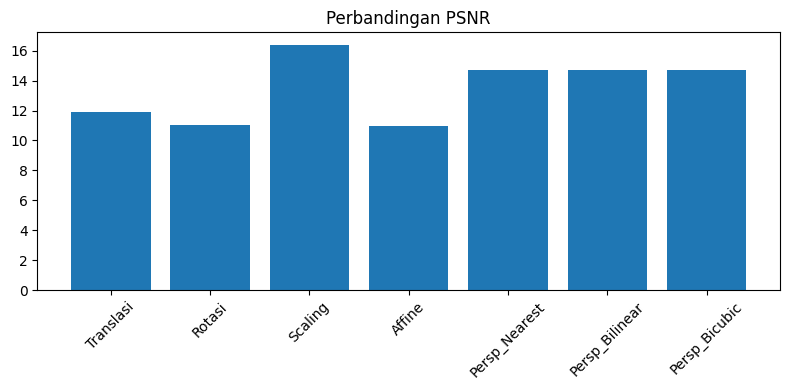

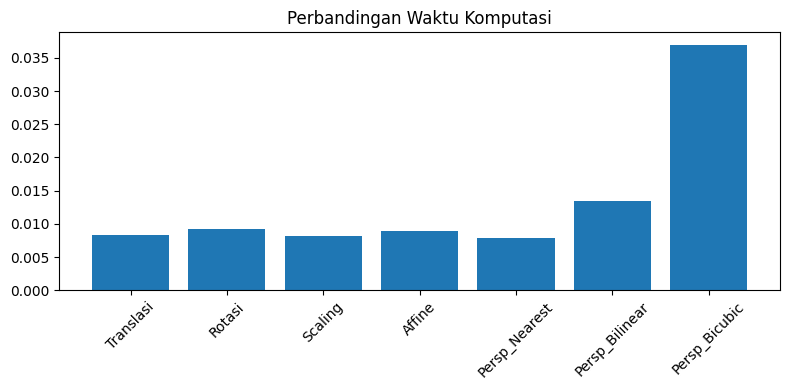


==================== SELESAI ====================



In [8]:
# ============================================================
# PIPELINE TRANSFORMASI GEOMETRIK UNTUK REGISTRASI CITRA
# ============================================================

print("\n==================== INSTALL LIBRARY ====================\n")
!pip install opencv-python

print("\n==================== IMPORT LIBRARY ====================\n")

import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
from google.colab import files
import math

print("Library berhasil di-import.")

# ============================================================
# UPLOAD GAMBAR
# ============================================================

print("\n==================== UPLOAD GAMBAR ====================\n")
print("Upload 2 gambar: (1) Referensi Lurus, (2) Gambar Miring)\n")

uploaded = files.upload()

images = []
for file in uploaded.keys():
    img = cv2.imread(file)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images.append(img)

if len(images) < 2:
    raise ValueError("Harus upload 2 gambar!")

img_ref = images[0]
img_move = images[1]

h, w = img_ref.shape[:2]
img_move = cv2.resize(img_move, (w, h))

print("\nGambar berhasil dimuat dan disamakan ukurannya.")

# ============================================================
# FUNGSI EVALUASI
# ============================================================

print("\n==================== DEFINISI FUNGSI EVALUASI ====================\n")

def mse(img1, img2):
    return np.mean((img1.astype("float32") - img2.astype("float32")) ** 2)

def psnr(img1, img2):
    mse_val = mse(img1, img2)
    if mse_val == 0:
        return 100
    return 20 * np.log10(255.0 / np.sqrt(mse_val))

results = {}

print("Fungsi MSE dan PSNR siap digunakan.")

# ============================================================
# TRANSLASI
# ============================================================

print("\n==================== TRANSLASI ====================\n")

Tx, Ty = 40, 30
M_trans = np.array([[1, 0, Tx],
                    [0, 1, Ty]], dtype=np.float32)

start = time.time()
translated = cv2.warpAffine(img_move, M_trans, (w, h))
time_trans = time.time() - start

results["Translasi"] = (mse(img_ref, translated),
                        psnr(img_ref, translated),
                        time_trans)

print("Translasi selesai.")

# ============================================================
# ROTASI
# ============================================================

print("\n==================== ROTASI ====================\n")

center = (w/2, h/2)
M_rot = cv2.getRotationMatrix2D(center, 15, 1.0)

start = time.time()
rotated = cv2.warpAffine(img_move, M_rot, (w, h))
time_rot = time.time() - start

results["Rotasi"] = (mse(img_ref, rotated),
                     psnr(img_ref, rotated),
                     time_rot)

print("Rotasi selesai.")

# ============================================================
# SCALING
# ============================================================

print("\n==================== SCALING ====================\n")

M_scale = cv2.getRotationMatrix2D(center, 0, 1.2)

start = time.time()
scaled = cv2.warpAffine(img_move, M_scale, (w, h))
time_scale = time.time() - start

results["Scaling"] = (mse(img_ref, scaled),
                      psnr(img_ref, scaled),
                      time_scale)

print("Scaling selesai.")

# ============================================================
# AFFINE
# ============================================================

print("\n==================== TRANSFORMASI AFFINE ====================\n")

pts1_aff = np.float32([[50,50],
                       [w-50,50],
                       [50,h-50]])

pts2_aff = np.float32([[10,80],
                       [w-80,40],
                       [80,h-80]])

M_affine = cv2.getAffineTransform(pts1_aff, pts2_aff)

start = time.time()
affine_result = cv2.warpAffine(img_move, M_affine, (w, h),
                               flags=cv2.INTER_LINEAR)
time_affine = time.time() - start

results["Affine"] = (mse(img_ref, affine_result),
                     psnr(img_ref, affine_result),
                     time_affine)

print("Affine selesai.")

# ============================================================
# PERSPEKTIF + INTERPOLASI
# ============================================================

print("\n==================== TRANSFORMASI PERSPEKTIF ====================\n")

pts1 = np.float32([[60,60],
                   [w-60,50],
                   [50,h-60],
                   [w-50,h-50]])

pts2 = np.float32([[0,0],
                   [w,0],
                   [0,h],
                   [w,h]])

M_persp = cv2.getPerspectiveTransform(pts1, pts2)

# Interpolasi
start = time.time()
nearest = cv2.warpPerspective(img_move, M_persp, (w,h),
                              flags=cv2.INTER_NEAREST)
time_nearest = time.time() - start
results["Persp_Nearest"] = (mse(img_ref, nearest),
                            psnr(img_ref, nearest),
                            time_nearest)

start = time.time()
bilinear = cv2.warpPerspective(img_move, M_persp, (w,h),
                               flags=cv2.INTER_LINEAR)
time_bilinear = time.time() - start
results["Persp_Bilinear"] = (mse(img_ref, bilinear),
                             psnr(img_ref, bilinear),
                             time_bilinear)

start = time.time()
bicubic = cv2.warpPerspective(img_move, M_persp, (w,h),
                              flags=cv2.INTER_CUBIC)
time_bicubic = time.time() - start
results["Persp_Bicubic"] = (mse(img_ref, bicubic),
                            psnr(img_ref, bicubic),
                            time_bicubic)

print("Perspective + 3 interpolasi selesai.")

# ============================================================
# VISUALISASI TRANSFORMASI DASAR + AFFINE
# ============================================================

print("\n==================== VISUALISASI TRANSFORMASI ====================\n")

plt.figure(figsize=(10,6))

plt.subplot(2,3,1)
plt.imshow(img_ref)
plt.title("Referensi")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(translated)
plt.title("Translasi")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(rotated)
plt.title("Rotasi")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(scaled)
plt.title("Scaling")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(affine_result)
plt.title("Affine")
plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# VISUALISASI INTERPOLASI PERSPEKTIF
# ============================================================

print("\n==================== VISUALISASI INTERPOLASI PERSPEKTIF ====================\n")

plt.figure(figsize=(9,4))

plt.subplot(1,3,1)
plt.imshow(nearest)
plt.title("Nearest")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(bilinear)
plt.title("Bilinear")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(bicubic)
plt.title("Bicubic")
plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# HASIL EVALUASI NUMERIK
# ============================================================

print("\n==================== HASIL EVALUASI ====================\n")

for k,v in results.items():
    print(k)
    print("MSE  :", round(v[0],4))
    print("PSNR :", round(v[1],4))
    print("Time :", round(v[2],5), "detik\n")

# ============================================================
# GRAFIK PERBANDINGAN
# ============================================================

print("\n==================== GRAFIK PERBANDINGAN ====================\n")

labels = list(results.keys())
psnr_vals = [results[k][1] for k in labels]
time_vals = [results[k][2] for k in labels]

plt.figure(figsize=(8,4))
plt.bar(labels, psnr_vals)
plt.xticks(rotation=45)
plt.title("Perbandingan PSNR")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.bar(labels, time_vals)
plt.xticks(rotation=45)
plt.title("Perbandingan Waktu Komputasi")
plt.tight_layout()
plt.show()

print("\n==================== SELESAI ====================\n")